In [4]:
!pip install pandas numpy matplotlib seaborn wordcloud kaggle

## Celda 2 - Imports

Se centralizan librerias y estilo visual para consistencia en graficas.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from IPython.display import display
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print('Librerias cargadas correctamente')

Librerias cargadas correctamente


## Celda 3 - Carga de datasets

Se usan rutas relativas desde la carpeta notebooks.

In [6]:
df_amazon = pd.read_csv('../data/amazon/Reviews.csv')
df_imdb = pd.read_csv('../data/imdb/IMDB_Dataset.csv')

print(f'Amazon shape: {df_amazon.shape}')
print(f'IMDB shape:   {df_imdb.shape}')

Amazon shape: (568454, 10)
IMDB shape:   (50000, 2)


## Celda 4 - Inspeccion basica Amazon

In [7]:
print('=' * 60)
print('AMAZON FINE FOOD REVIEWS - Inspeccion basica')
print('=' * 60)

print()
print('Primeras 3 filas:')
display(df_amazon.head(3))

print()
print('Columnas disponibles:')
print(df_amazon.columns.tolist())

print()
print('Tipos de datos:')
print(df_amazon.dtypes)

print()
print('Valores nulos por columna:')
print(df_amazon.isnull().sum())

print()
print('Shape:', df_amazon.shape)

AMAZON FINE FOOD REVIEWS - Inspeccion basica

Primeras 3 filas:


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...



Columnas disponibles:
['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text']

Tipos de datos:
Id                         int64
ProductId                 object
UserId                    object
ProfileName               object
HelpfulnessNumerator       int64
HelpfulnessDenominator     int64
Score                      int64
Time                       int64
Summary                   object
Text                      object
dtype: object

Valores nulos por columna:
Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
dtype: int64

Shape: (568454, 10)


## Celda 5 - Inspeccion basica IMDB

In [8]:
print('=' * 60)
print('IMDB 50K MOVIE REVIEWS - Inspeccion basica')
print('=' * 60)

print()
print('Primeras 3 filas:')
display(df_imdb.head(3))

print()
print('Columnas disponibles:')
print(df_imdb.columns.tolist())

print()
print('Tipos de datos:')
print(df_imdb.dtypes)

print()
print('Valores nulos por columna:')
print(df_imdb.isnull().sum())

print()
print('Shape:', df_imdb.shape)

IMDB 50K MOVIE REVIEWS - Inspeccion basica

Primeras 3 filas:


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive



Columnas disponibles:
['review', 'sentiment']

Tipos de datos:
review       object
sentiment    object
dtype: object

Valores nulos por columna:
review       0
sentiment    0
dtype: int64

Shape: (50000, 2)


## Celda 6 - Estandarizacion de etiquetas

In [9]:
df_amazon_clean = df_amazon[df_amazon['Score'] != 3].copy()
df_amazon_clean['label'] = df_amazon_clean['Score'].apply(lambda x: 1 if x >= 4 else 0)
df_amazon_clean['text'] = df_amazon_clean['Text']
df_amazon_clean = df_amazon_clean[['text', 'label']]

df_imdb_clean = df_imdb.copy()
df_imdb_clean['label'] = df_imdb_clean['sentiment'].map({'positive': 1, 'negative': 0})
df_imdb_clean['text'] = df_imdb_clean['review']
df_imdb_clean = df_imdb_clean[['text', 'label']]

print('Amazon limpio:', df_amazon_clean.shape)
print('IMDB limpio:  ', df_imdb_clean.shape)
print('Valores unicos de label en Amazon:', sorted(df_amazon_clean['label'].dropna().unique()))
print('Valores unicos de label en IMDB:  ', sorted(df_imdb_clean['label'].dropna().unique()))

Amazon limpio: (525814, 2)
IMDB limpio:   (50000, 2)
Valores unicos de label en Amazon: [0, 1]
Valores unicos de label en IMDB:   [0, 1]


## Celda 7 - Distribucion de clases (Visualizacion 1)

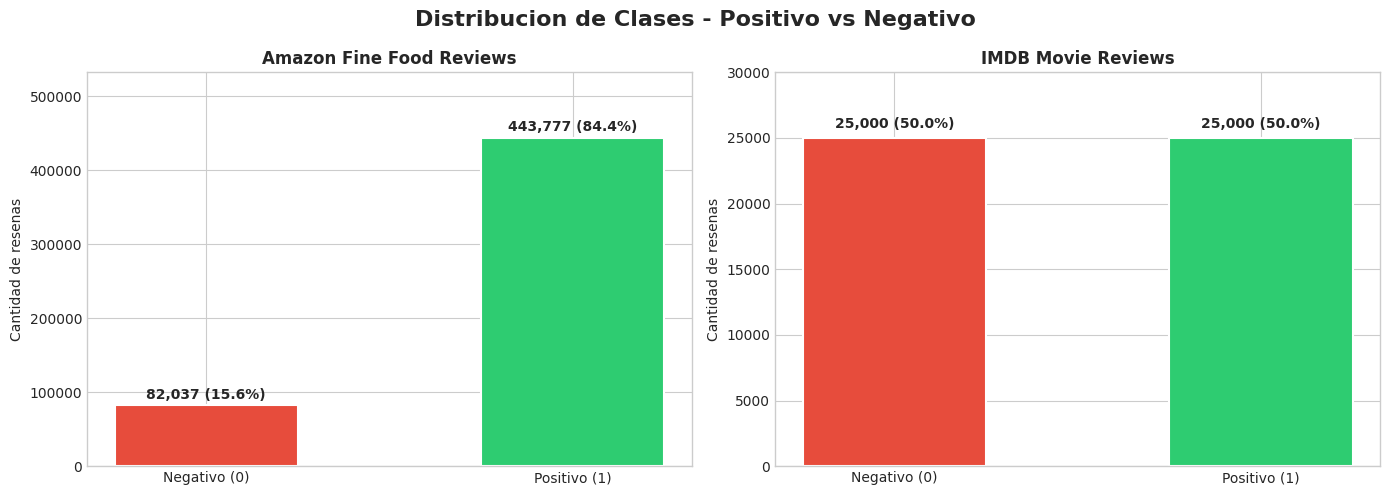

RESUMEN DE BALANCE DE CLASES
----------------------------------------

Amazon Fine Food Reviews:
  Positivos: 443,777 (84.4%)
  Negativos: 82,037 (15.6%)
  Ratio pos/neg: 5.41

IMDB Movie Reviews:
  Positivos: 25,000 (50.0%)
  Negativos: 25,000 (50.0%)
  Ratio pos/neg: 1.00


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribucion de Clases - Positivo vs Negativo', fontsize=16, fontweight='bold')

datasets = {'Amazon Fine Food Reviews': df_amazon_clean, 'IMDB Movie Reviews': df_imdb_clean}

for ax, (nombre, df) in zip(axes, datasets.items()):
    conteo = df['label'].value_counts()
    colores = ['#e74c3c', '#2ecc71']
    barras = ax.bar(['Negativo (0)', 'Positivo (1)'], [conteo.get(0, 0), conteo.get(1, 0)], color=colores, edgecolor='white', linewidth=1.5, width=0.5)

    total = len(df)
    for barra in barras:
        altura = barra.get_height()
        ax.text(barra.get_x() + barra.get_width() / 2, altura + total * 0.01, f'{altura:,} ({altura / total * 100:.1f}%)', ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax.set_title(nombre, fontsize=12, fontweight='bold')
    ax.set_ylabel('Cantidad de resenas')
    ax.set_ylim(0, max(conteo) * 1.2)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('RESUMEN DE BALANCE DE CLASES')
print('-' * 40)
for nombre, df in datasets.items():
    conteo = df['label'].value_counts()
    neg = conteo.get(0, 0)
    pos = conteo.get(1, 0)
    ratio = pos / max(1, neg)
    print()
    print(f'{nombre}:')
    print(f'  Positivos: {pos:,} ({pos / len(df) * 100:.1f}%)')
    print(f'  Negativos: {neg:,} ({neg / len(df) * 100:.1f}%)')
    print(f'  Ratio pos/neg: {ratio:.2f}')

## Celda 8 - Longitud de resenas (Visualizacion 2)

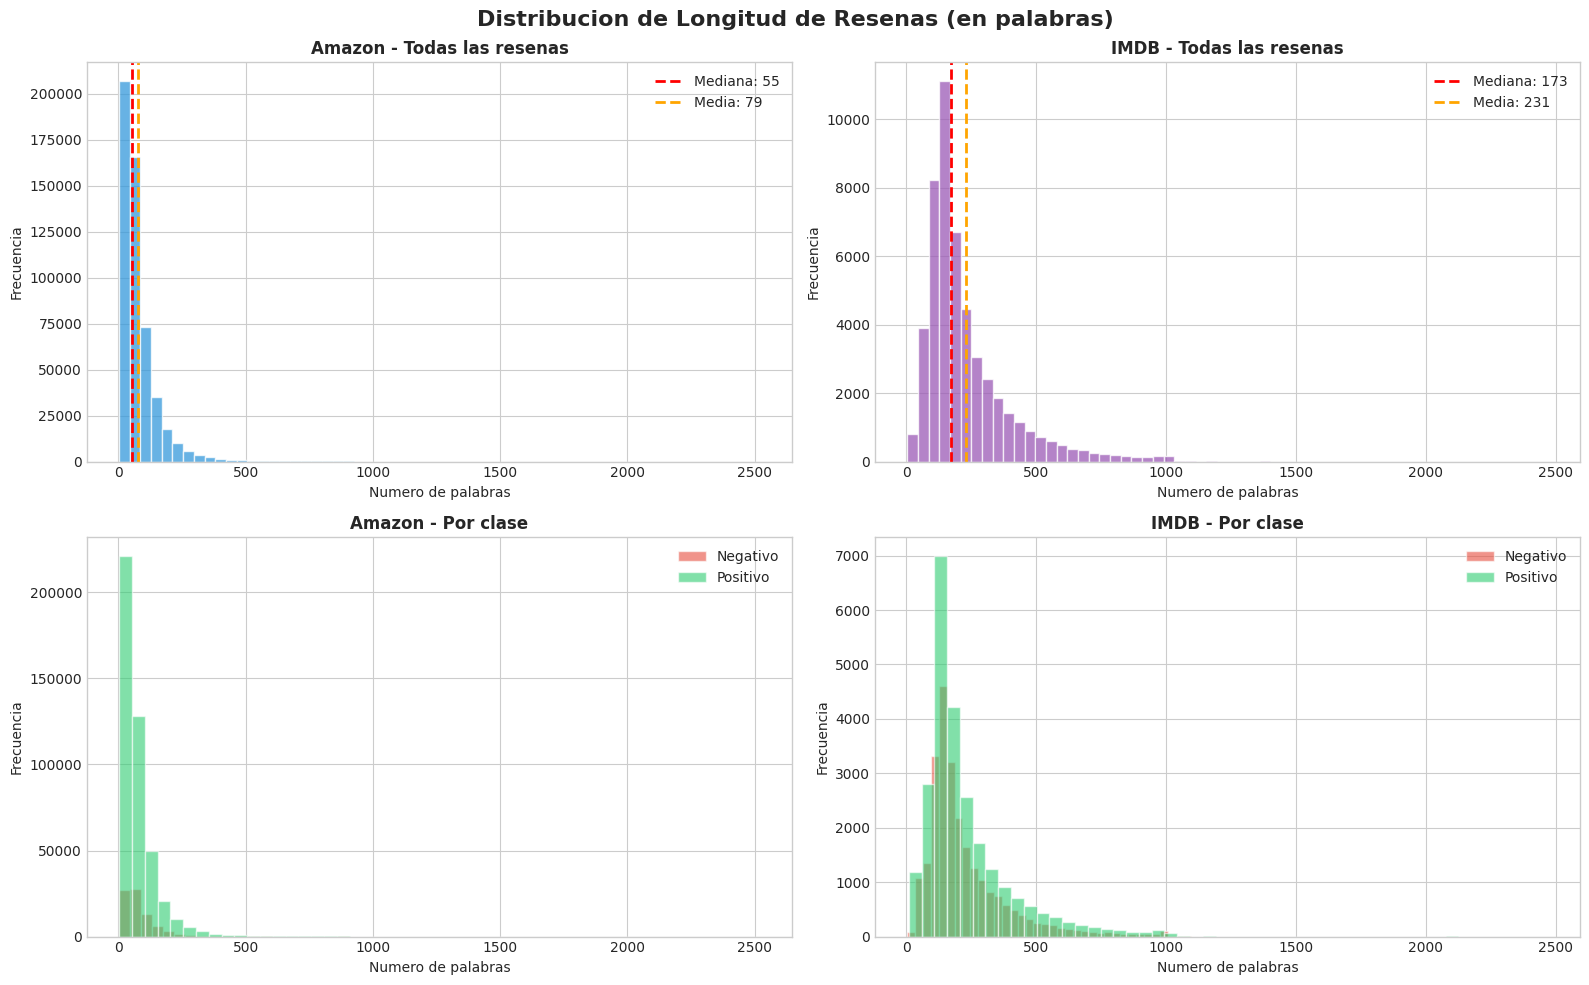

ESTADISTICAS DE LONGITUD
--------------------------------------------------

Amazon:
  Media:    79.0 palabras
  Mediana:  55.0 palabras
  Minimo:   3 palabras
  Maximo:   2520 palabras
  Percentil 95: 215 palabras

IMDB:
  Media:    231.2 palabras
  Mediana:  173.0 palabras
  Minimo:   4 palabras
  Maximo:   2470 palabras
  Percentil 95: 590 palabras


In [11]:
df_amazon_clean['num_palabras'] = df_amazon_clean['text'].astype(str).str.split().str.len()
df_imdb_clean['num_palabras'] = df_imdb_clean['text'].astype(str).str.split().str.len()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Distribucion de Longitud de Resenas (en palabras)', fontsize=16, fontweight='bold')

configs = [
    (axes[0, 0], df_amazon_clean, 'Amazon - Todas las resenas', '#3498db'),
    (axes[0, 1], df_imdb_clean, 'IMDB - Todas las resenas', '#9b59b6')
]

for ax, df, titulo, color in configs:
    ax.hist(df['num_palabras'], bins=60, color=color, alpha=0.75, edgecolor='white')
    ax.axvline(df['num_palabras'].median(), color='red', linestyle='--', linewidth=2, label=f"Mediana: {df['num_palabras'].median():.0f}")
    ax.axvline(df['num_palabras'].mean(), color='orange', linestyle='--', linewidth=2, label=f"Media: {df['num_palabras'].mean():.0f}")
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.set_xlabel('Numero de palabras')
    ax.set_ylabel('Frecuencia')
    ax.legend()

for clase, color, label in [(0, '#e74c3c', 'Negativo'), (1, '#2ecc71', 'Positivo')]:
    subset = df_amazon_clean[df_amazon_clean['label'] == clase]['num_palabras']
    axes[1, 0].hist(subset, bins=50, alpha=0.6, color=color, label=label, edgecolor='white')
axes[1, 0].set_title('Amazon - Por clase', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Numero de palabras')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].legend()

for clase, color, label in [(0, '#e74c3c', 'Negativo'), (1, '#2ecc71', 'Positivo')]:
    subset = df_imdb_clean[df_imdb_clean['label'] == clase]['num_palabras']
    axes[1, 1].hist(subset, bins=50, alpha=0.6, color=color, label=label, edgecolor='white')
axes[1, 1].set_title('IMDB - Por clase', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Numero de palabras')
axes[1, 1].set_ylabel('Frecuencia')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('longitud_resenas.png', dpi=150, bbox_inches='tight')
plt.show()

print('ESTADISTICAS DE LONGITUD')
print('-' * 50)
for nombre, df in [('Amazon', df_amazon_clean), ('IMDB', df_imdb_clean)]:
    print()
    print(f'{nombre}:')
    print(f"  Media:    {df['num_palabras'].mean():.1f} palabras")
    print(f"  Mediana:  {df['num_palabras'].median():.1f} palabras")
    print(f"  Minimo:   {df['num_palabras'].min()} palabras")
    print(f"  Maximo:   {df['num_palabras'].max()} palabras")
    print(f"  Percentil 95: {df['num_palabras'].quantile(0.95):.0f} palabras")

## Celda 9 - Ejemplos de resenas reales

In [12]:
def print_samples(df, dataset_name):
    print('=' * 70)
    print(f'EJEMPLOS DE RESENAS - {dataset_name}')
    print('=' * 70)

    for label_value, label_name in [(1, 'POSITIVAS'), (0, 'NEGATIVAS')]:
        subset = df[df['label'] == label_value]
        n = min(3, len(subset))
        print()
        print(f'{label_name} (label={label_value}):')
        if n == 0:
            print('Sin ejemplos disponibles para esta clase.')
            continue

        for _, row in subset.sample(n, random_state=42).iterrows():
            text = str(row['text'])[:300].replace('\n', ' ')
            print()
            print(f"[{row['num_palabras']} palabras] {text}...")
            print('-' * 60)

print_samples(df_amazon_clean, 'AMAZON')
print()
print_samples(df_imdb_clean, 'IMDB')

EJEMPLOS DE RESENAS - AMAZON

POSITIVAS (label=1):

[95 palabras] I have started every morning for the last 7 months with a cup of Ganocafe Classic coffee. In my opinion it must be providing some benefits, I haven't had even one cold or any flu in that time. At age 71 years my blood pressure is lower than my doctor's nurse. I actually generally just feel better al...
------------------------------------------------------------

[71 palabras] Thank goodness this pasta makes life for a gluten-free lifestyle so much more enjoyable.  It cooks with enough firm texture, unlike other gluten-free items that become too soggy or a mush.  The pasta goes well in Greek tomato-based dishes, in a pasta dish with only olive oil, sardines, garlic, and c...
------------------------------------------------------------

[71 palabras] I am the type of person who gets tired and starts yawning when I am out at a bar... that is untill I discovered Rock Star.  This one is my favorite flavor, but they all get t

## Celda 10 - Nube de palabras (Visualizacion 3)

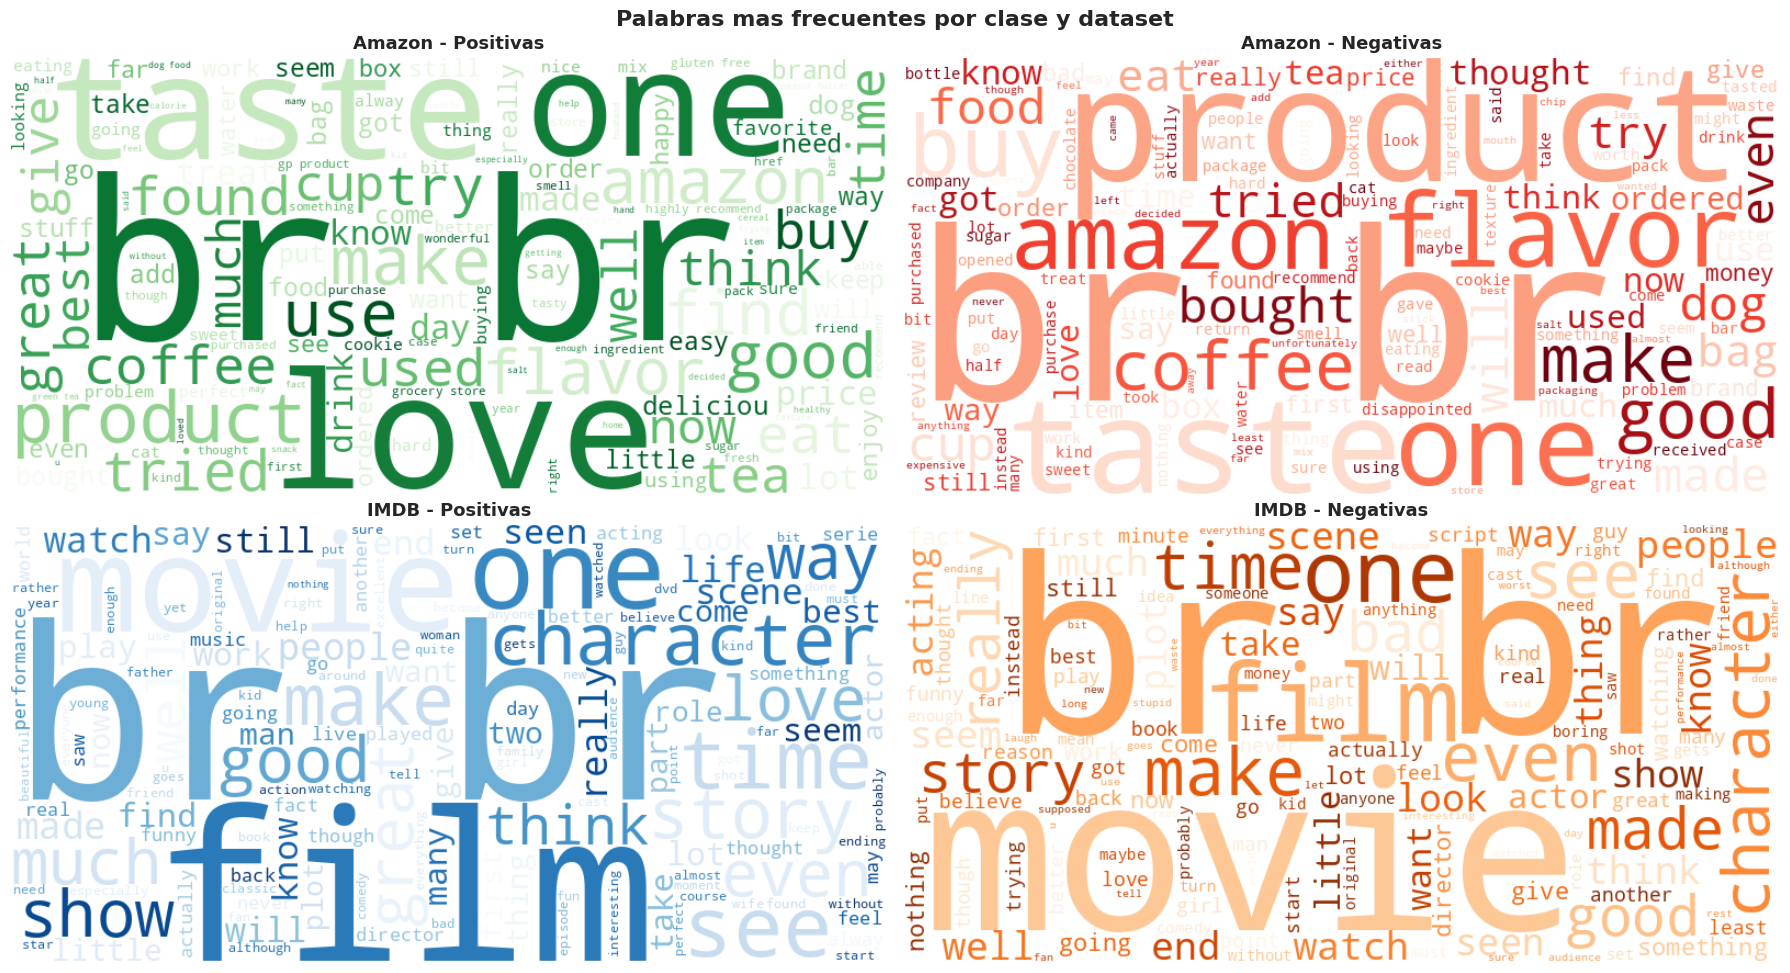

In [13]:
def generar_wordcloud(df, label, color_map):
    texto = ' '.join(df[df['label'] == label]['text'].astype(str).str.lower().values)
    return WordCloud(width=800, height=400, background_color='white', colormap=color_map, max_words=150, stopwords=None).generate(texto if texto.strip() else 'empty')

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle('Palabras mas frecuentes por clase y dataset', fontsize=16, fontweight='bold')

configs = [
    (axes[0, 0], df_amazon_clean, 1, 'Greens', 'Amazon - Positivas'),
    (axes[0, 1], df_amazon_clean, 0, 'Reds', 'Amazon - Negativas'),
    (axes[1, 0], df_imdb_clean, 1, 'Blues', 'IMDB - Positivas'),
    (axes[1, 1], df_imdb_clean, 0, 'Oranges', 'IMDB - Negativas')
]

for ax, df, label, cmap, titulo in configs:
    wc = generar_wordcloud(df, label, cmap)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(titulo, fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

## Celda 11 - Resumen final del EDA

In [14]:
print('=' * 60)
print('RESUMEN FINAL DEL EDA')
print('=' * 60)

for nombre, df in [('Amazon', df_amazon_clean), ('IMDB', df_imdb_clean)]:
    total = len(df)
    pos = int((df['label'] == 1).sum())
    neg = int((df['label'] == 0).sum())
    mediana = df['num_palabras'].median()
    p95 = df['num_palabras'].quantile(0.95)
    desbalance = abs(pos / max(1, total) - 0.5) > 0.1

    print()
    print(f'--- {nombre} ---')
    print(f'Total resenas:    {total:,}')
    print(f'Positivas:        {pos:,} ({pos / total * 100:.1f}%)')
    print(f'Negativas:        {neg:,} ({neg / total * 100:.1f}%)')
    print(f'Mediana palabras: {mediana:.0f}')
    print(f'Percentil 95:     {p95:.0f} palabras')
    print('Desbalance:       SI - considerar estratificacion' if desbalance else 'Desbalance:       NO - dataset cercano a balanceado')

print('CONCLUSIONES PARA PREPROCESAMIENTO:')
print('1. Eliminar tags HTML (ej. <br />, <a href>)')
print('2. Convertir texto a minusculas')
print('3. Eliminar puntuacion y caracteres especiales')
print('4. Eliminar stopwords en ingles para modelos clasicos')
print('5. Definir max_length basado en percentil 95')
print('6. Usar estratificacion en train/test split si hay desbalance')
print('7. Para Transformer, no eliminar stopwords de forma agresiva')

RESUMEN FINAL DEL EDA

--- Amazon ---
Total resenas:    525,814
Positivas:        443,777 (84.4%)
Negativas:        82,037 (15.6%)
Mediana palabras: 55
Percentil 95:     215 palabras
Desbalance:       SI - considerar estratificacion

--- IMDB ---
Total resenas:    50,000
Positivas:        25,000 (50.0%)
Negativas:        25,000 (50.0%)
Mediana palabras: 173
Percentil 95:     590 palabras
Desbalance:       NO - dataset cercano a balanceado
CONCLUSIONES PARA PREPROCESAMIENTO:
1. Eliminar tags HTML (ej. <br />, <a href>)
2. Convertir texto a minusculas
3. Eliminar puntuacion y caracteres especiales
4. Eliminar stopwords en ingles para modelos clasicos
5. Definir max_length basado en percentil 95
6. Usar estratificacion en train/test split si hay desbalance
7. Para Transformer, no eliminar stopwords de forma agresiva


## Cobertura de rubrica

| Requisito rubrica | Cubierto en |
|---|---|
| Distribucion de clases | Celda 7 |
| Desbalance de clases | Celdas 7 y 11 |
| Ejemplos de muestras | Celda 9 |
| Minimo 2 visualizaciones | Celdas 7, 8 y 10 |
| Descripcion del dataset | Celdas 4, 5 y 11 |